In [1]:
cd ..

e:\notebooks\MultimodalTweetsClassification


In [3]:
#ensuring that any edits to libraries you make are reloaded here automatically
#to ensuere charts or images displayed are shown in this notebook
%reload_ext autoreload
%autoreload 2
%matplotlib inline 

In [2]:
import sys
import os

# Add project root (change if needed)
project_root = r"E:\notebooks\MultimodalTweetsClassification"
sys.path.append(project_root)

from exp.Required_Modules_And_Packages import *
from sample_data.Data_Reading_And_Preprocessing import *


In [5]:
path = Path('/notebooks/MultimodalTweetsClassification')
# path.ls()

In [6]:
path_img = path/'data_image'

In [7]:
data_human_text_image,test_data_human_text_image = get_dataframe(*get_tsv_data_files('Informativeness_task_tsv_files'),path)

reading data and preprocessing it.....
done!!


In [8]:
print(f"shape of data: {data_human_text_image.shape}\n")
print(f"train set: {data_human_text_image['is_valid'].value_counts()[0]}")
print(f"valid set: {data_human_text_image['is_valid'].value_counts()[1]}")      
print("="*50)
print(f"shape of test data: {test_data_human_text_image.shape}\n")

shape of data: (914, 10)

train set: 804
valid set: 110
shape of test data: (107, 9)



In [9]:
data_human_text_image.head()

,event_name,tweet_id,image_id,tweet_text,image,label,label_text,label_image,label_text_image,is_valid
0,srilanka_floods,8.700000e+17,869972354004393987_1,pak navy continues humanitarian assistance and...,data_image/srilanka_floods/31_5_2017/869972354...,informative,informative,informative,Positive,False
1,srilanka_floods,8.700000e+17,869972354004393987_2,pak navy continues humanitarian assistance and...,data_image/srilanka_floods/31_5_2017/869972354...,informative,informative,informative,Positive,False
2,srilanka_floods,8.700000e+17,869972354004393987_3,pak navy continues humanitarian assistance and...,data_image/srilanka_floods/31_5_2017/869972354...,informative,informative,informative,Positive,False
3,srilanka_floods,8.700000e+17,869977622377320448_0,sentinel was used to map the flood in matara s...,data_image/srilanka_floods/31_5_2017/869977622...,not_informative,informative,not_informative,Negative,False
4,srilanka_floods,8.700000e+17,869977622377320448_1,sentinel was used to map the flood in matara s...,data_image/srilanka_floods/31_5_2017/869977622...,informative,informative,not_informative,Negative,False


In [10]:
from transformers import BertTokenizer, BertForSequenceClassification
from exp.Required_Integration_Functionalities_For_Transformer_To_Fastai import (
    TransformersBaseTokenizer, TransformersVocab, CustomTransformerModel
)
from exp.Required_Modules_And_Packages import *
from exp.Data_Reading_And_Preprocessing import *

In [11]:
num_labels = len(data_human_text_image['label_text'].unique())
model_path = r"e:\notebooks\MultimodalTweetsClassification\bert_model"
hf_tokenizer = BertTokenizer.from_pretrained(model_path)
# hf_model = BertForSequenceClassification.from_pretrained(model_path, num_labels=num_labels)


from transformers import BertForSequenceClassification
import torch.nn as nn

# Load with original shape (8 labels)
hf_model = BertForSequenceClassification.from_pretrained(model_path, num_labels=8)

# Replace classifier for 2 labels
hf_model.classifier = nn.Linear(hf_model.config.hidden_size, num_labels)
hf_model.config.num_labels = num_labels


In [12]:
fastai_tokenizer = TransformersBaseTokenizer(hf_tokenizer)
fastai_vocab = TransformersVocab(hf_tokenizer)

In [13]:
from fastai.text import Tokenizer, TokenizeProcessor, NumericalizeProcessor

fastai_tokenizer = Tokenizer(
    tok_func=TransformersBaseTokenizer(hf_tokenizer, model_type='bert'),
    pre_rules=[], post_rules=[], n_cpus=1
)
fastai_vocab = TransformersVocab(hf_tokenizer)

processor = [TokenizeProcessor(tokenizer=fastai_tokenizer), NumericalizeProcessor(vocab=fastai_vocab)]



def get_text_data(dataframe, path, pad_first=True, pad_idx=1, batch_size=64, processor=None, vocab=None, num_workers=0):
    text_data = (TextList.from_df(dataframe, path, cols='tweet_text', processor=processor, vocab=vocab)
                 .split_from_df(col='is_valid')
                 .label_from_df(cols='label_text')
                 .databunch(bs=batch_size, pad_first=pad_first, pad_idx=pad_idx, num_workers=num_workers))
    return text_data

# function to create databunch object of test text data using test split

def get_test_text_data(dataframe, path, pad_first=True, pad_idx=1, batch_size=64, processor=None, vocab=None, num_workers=0):
    test_text_data = (TextList.from_df(dataframe, path, cols='tweet_text', processor=processor, vocab=vocab)
                      .split_none()
                      .label_from_df(cols='label_text')
                      .databunch(bs=batch_size, pad_first=pad_first, pad_idx=pad_idx, num_workers=num_workers))
    return test_text_data


data_clas = get_text_data(
    data_human_text_image,
    path,
    processor=processor,
    vocab=fastai_vocab
)
test_data_clas = get_test_text_data(
    test_data_human_text_image,
    path,
    processor=processor,
    vocab=fastai_vocab
)
data_clas.add_test(test_data_clas.train_ds)
data_clas.test_ds.y = test_data_clas.train_ds.y

In [14]:
pad_idx = hf_tokenizer.pad_token_id
model = CustomTransformerModel(pad_idx, hf_model)

In [15]:
from torch.nn import CrossEntropyLoss

learn_clas = Learner(
    data_clas,
    model,
    loss_func=CrossEntropyLoss(),
    metrics=[accuracy, Precision1(average='macro'), Precision1(average='weighted')],
    callback_fns=[ShowGraph]
)

In [16]:
# learn_clas.lr_find()
# learn_clas.recorder.plot(suggestion=True)

epoch,train_loss,valid_loss,accuracy,precision1,precision1,time
0,0.276562,0.193138,0.936364,0.929435,0.941312,01:37


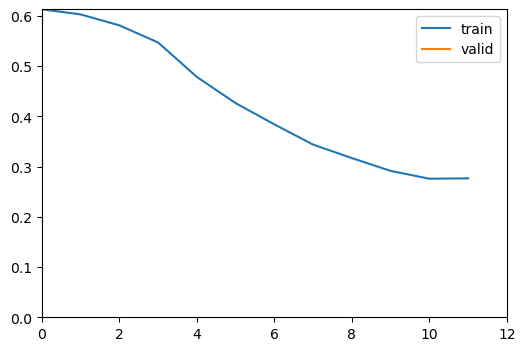

In [17]:
learn_clas.fit_one_cycle(1, 1e-4)

              precision    recall  f1-score   support

        INFO       0.88      0.98      0.92        43
  Non - Info       0.98      0.91      0.95        67

    accuracy                           0.94       110
   macro avg       0.93      0.94      0.93       110
weighted avg       0.94      0.94      0.94       110



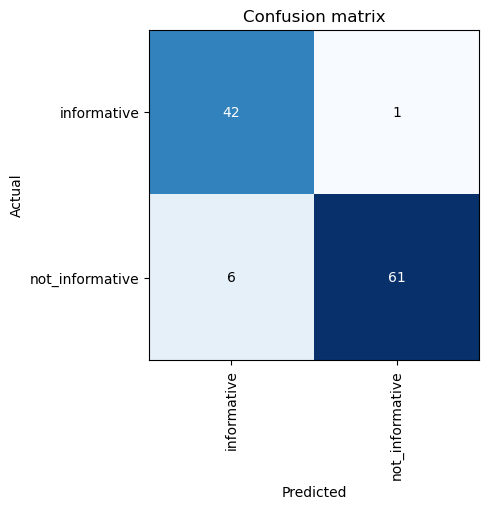

In [18]:
interp = ClassificationInterpretation.from_learner(learn_clas)
interp.plot_confusion_matrix(figsize=(5,5), dpi=100)

preds, y, losses = learn_clas.get_preds(ds_type=DatasetType.Valid, with_loss=True)
y_preds = preds.argmax(1)

target_names = [
    'INFO',
    'Non - Info',
]
print(classification_report(y, y_preds, target_names=target_names))

## Image

In [ ]:
# #reading csv files and doing initial necessary processing
# data_human_text_image,test_data_human_text_image = get_dataframe(*get_tsv_data_files('Informativeness_task_tsv_files'),path)

reading data and preprocessing it.....
done!!


In [ ]:
# print(f"shape of data: {data_human_text_image.shape}\n")
# print(f"train set: {data_human_text_image['is_valid'].value_counts()[0]}")
# print(f"valid set: {data_human_text_image['is_valid'].value_counts()[1]}")      
# print("="*50)
# print(f"shape of test data: {test_data_human_text_image.shape}\n")

shape of data: (15844, 10)

train set: 13607
valid set: 2237
shape of test data: (2237, 9)



In [21]:
data_human_text_image.head()

,event_name,tweet_id,image_id,tweet_text,image,label,label_text,label_image,label_text_image,is_valid
0,california_wildfires,917791291823591425,917791291823591425_1,pls share were capturing wildfire response rec...,data_image/california_wildfires/10_10_2017/917...,not_informative,informative,not_informative,Negative,False
1,california_wildfires,917793137925459968,917793137925459968_0,california wildfires destroy more than structu...,data_image/california_wildfires/10_10_2017/917...,informative,informative,informative,Positive,False
2,california_wildfires,917793137925459968,917793137925459968_1,california wildfires destroy more than structu...,data_image/california_wildfires/10_10_2017/917...,informative,informative,informative,Positive,False
3,california_wildfires,917793137925459968,917793137925459968_2,california wildfires destroy more than structu...,data_image/california_wildfires/10_10_2017/917...,informative,informative,informative,Positive,False
4,california_wildfires,917815040962695168,917815040962695168_0,photos of california destructive wildfires via,data_image/california_wildfires/10_10_2017/917...,informative,informative,informative,Positive,False


In [22]:
#creating text databunch object for data(train and dev split) and test data(test split)
data_img = get_image_data(data_human_text_image,path,224)
test_data_img = get_test_image_data(test_data_human_text_image,path,224)

In [23]:
# making single databunch object of data and test data
data_img.add_test(test_data_img.x)
data_img.test_ds.y = test_data_img.y

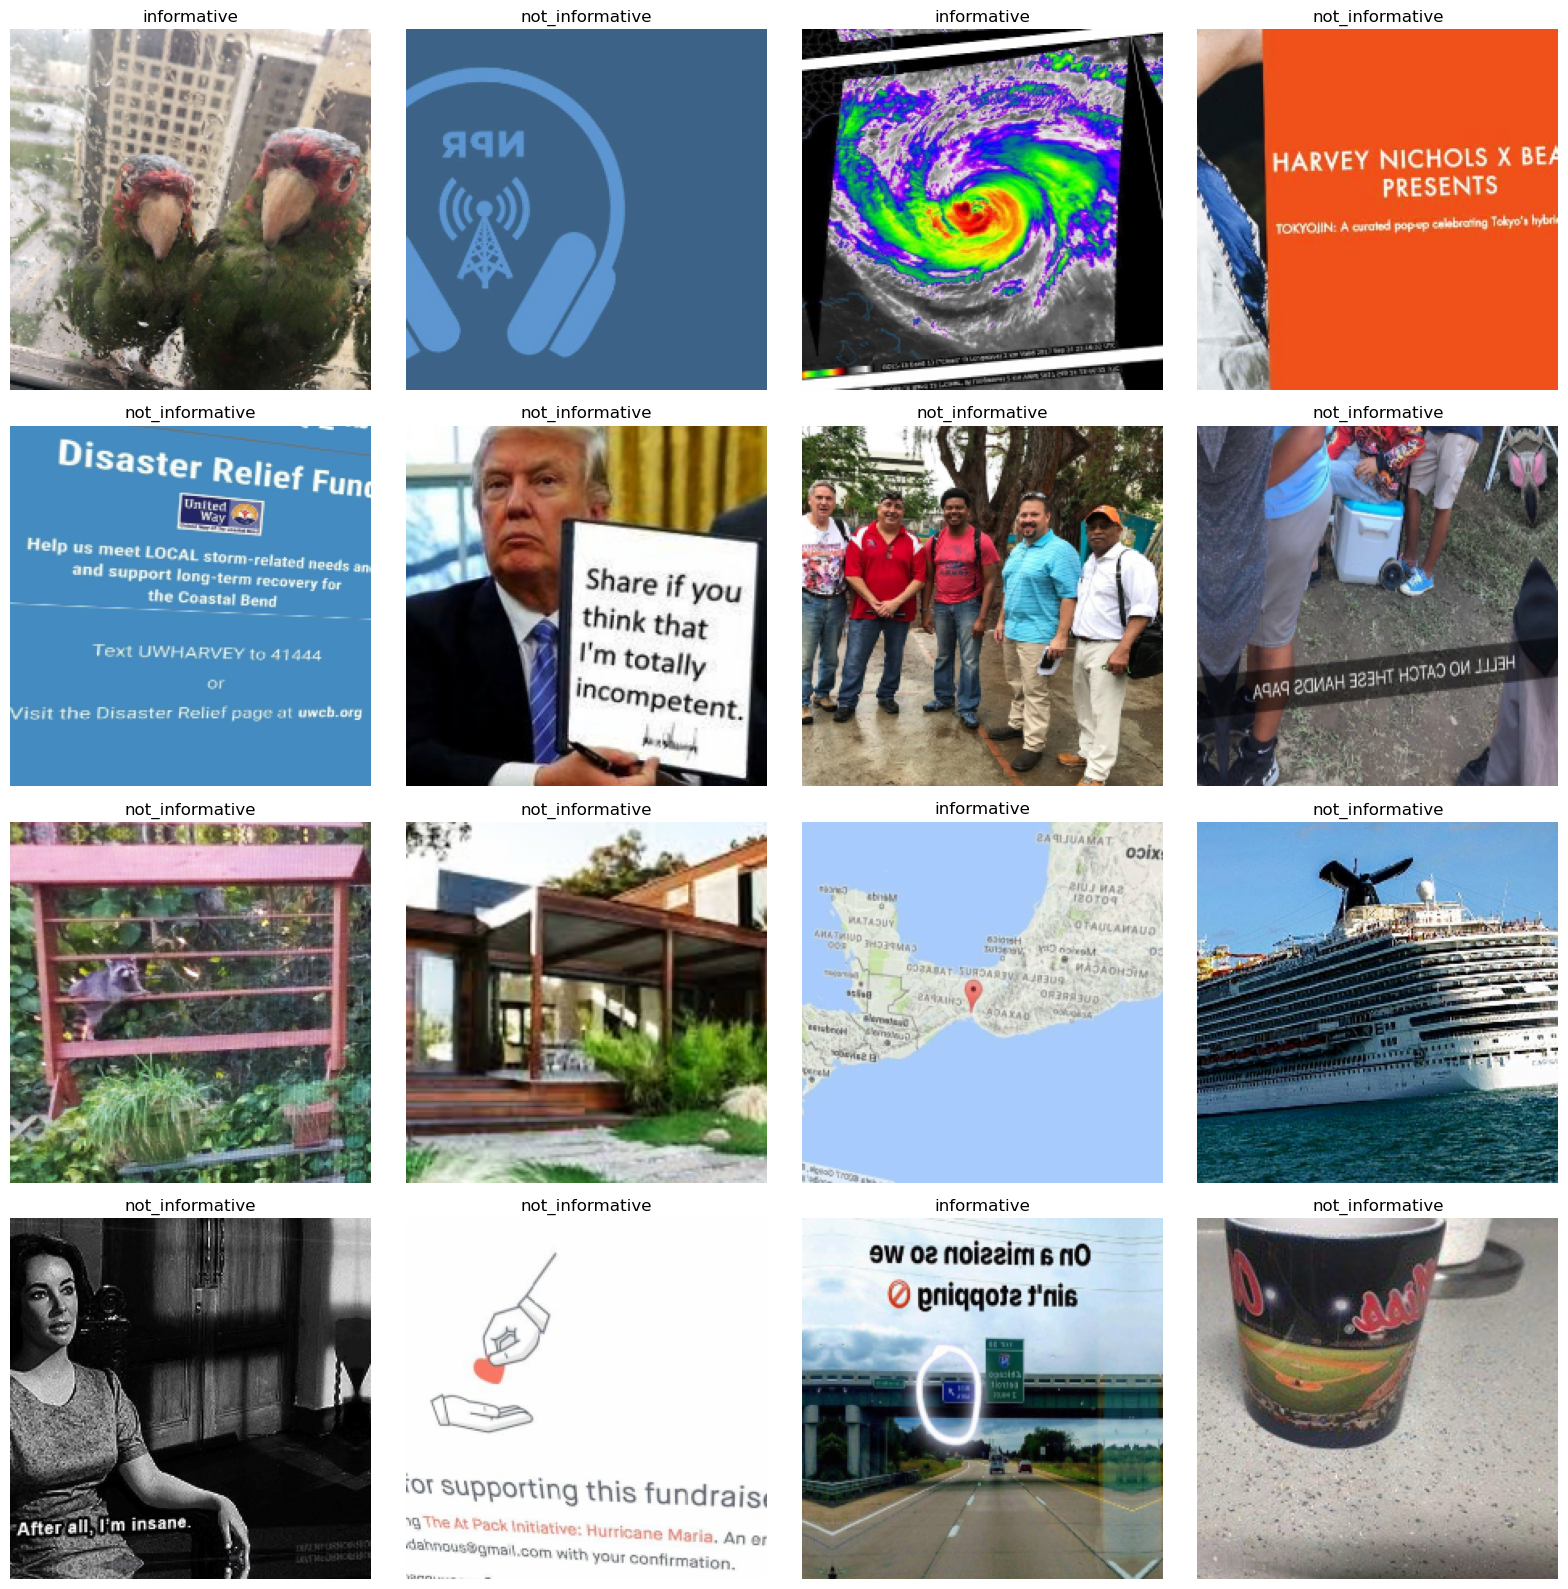

In [24]:
# showing the data with corresponding label
data_img.show_batch()

In [25]:
# importing pretrained 
# and making learner object consist of data,model,metrics and callbacks for training
arch = models.resnet50
learn_img = cnn_learner(data_img, arch, metrics=[accuracy,Precision1(average='macro'),
                Precision1(average='weighted'),Recall(average='macro'),Recall(average='weighted'),
               FBeta(average='macro',beta=1.),FBeta(average='weighted',beta=1.)],
            callback_fns=[ShowGraph,partial(EarlyStoppingCallback, monitor='valid_loss', min_delta=0.01, patience=3),
               partial(ReduceLROnPlateauCallback,monitor='valid_loss', mode='auto', patience=0,
                       factor=0.2, min_delta=0, min_lr=0.000001)])          

In [ ]:
learn_img.lr_find()

In [ ]:
learn_img.recorder.plot()

In [28]:
# training the model's top layer's keeping other layer's in freezing mode, all the metric shown here, have been
# evaluted on validation set
lr = 0.0001
learn_img.fit_one_cycle(1, slice(lr))

epoch,train_loss,valid_loss,accuracy,precision1,precision1,recall,recall,f_beta,f_beta,time


KeyboardInterrupt: 

In [ ]:
# unfreezing bottom layer's
learn_img.unfreeze()

In [ ]:
# learn_img.lr_find()
# learn_img.recorder.plot()

In [ ]:
#training model the with all the layer's and saving the best one, and displaying the loss during training
learn_img.fit_one_cycle(1, slice(1e-4, 1e-3),
                        callbacks=[SaveModelCallback(learn_img,every='improvement', monitor='accuracy', name='best')])

In [ ]:
# making interpretation on dev split
interp = ClassificationInterpretation.from_learner(learn_img)

In [ ]:
# plotting confusion matrix
interp.plot_confusion_matrix(figsize=(3,3), dpi=100)

In [ ]:
#making predictions on validation set to use it in classification report
preds,y,losses = learn_img.get_preds(ds_type=DatasetType.Valid,with_loss=True)
y_preds = preds.argmax(1)

In [ ]:
target_names = ['Informative', 'Non-Informative']

print(classification_report(y, y_preds, target_names=target_names))

In [ ]:
learn_img.validate(data_img.test_dl,metrics=[accuracy,Precision(average='macro'),Precision(average='weighted'),
                                                 Recall(average='macro'),Recall(average='weighted'),
                                                 FBeta(average='macro',beta=1.),FBeta(average='weighted',beta=1.)])

In [ ]:
preds,y,losses = learn_img.get_preds(ds_type=DatasetType.Test,with_loss=True)
y_preds = preds.argmax(1)
print(classification_report(y, y_preds, target_names=target_names))

In [ ]:
#making interpretation on test split
interp = ClassificationInterpretation.from_learner(learn_img,ds_type=DatasetType.Test)
interp.plot_confusion_matrix(figsize=(3,3), dpi=100)